In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [2]:
train_dir = "Apple/Train/"
test_dir = "Apple/Test/"


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=16,
    class_mode='categorical',
    subset='validation'
)

Found 5695 images belonging to 4 classes.
Found 1423 images belonging to 4 classes.


In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(train_data.num_classes, activation='softmax')
])


In [5]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [6]:
# Train Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5,
)

Epoch 1/5
356/356 [==============================] - 119s 329ms/step - loss: 0.5628 - accuracy: 0.7838 - val_loss: 0.2927 - val_accuracy: 0.8904
Epoch 2/5
356/356 [==============================] - 152s 427ms/step - loss: 0.2919 - accuracy: 0.8938 - val_loss: 0.2786 - val_accuracy: 0.9079
Epoch 3/5
356/356 [==============================] - 163s 458ms/step - loss: 0.2242 - accuracy: 0.9212 - val_loss: 0.2102 - val_accuracy: 0.9255
Epoch 4/5
356/356 [==============================] - 159s 447ms/step - loss: 0.1826 - accuracy: 0.9342 - val_loss: 0.1399 - val_accuracy: 0.9522
Epoch 5/5
356/356 [==============================] - 166s 465ms/step - loss: 0.1714 - accuracy: 0.9401 - val_loss: 0.1034 - val_accuracy: 0.9613


In [7]:
# Evaluate Model
loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)

89/89 [==============================] - 20s 223ms/step - loss: 0.1045 - accuracy: 0.9670
Validation Accuracy: 0.9669711589813232


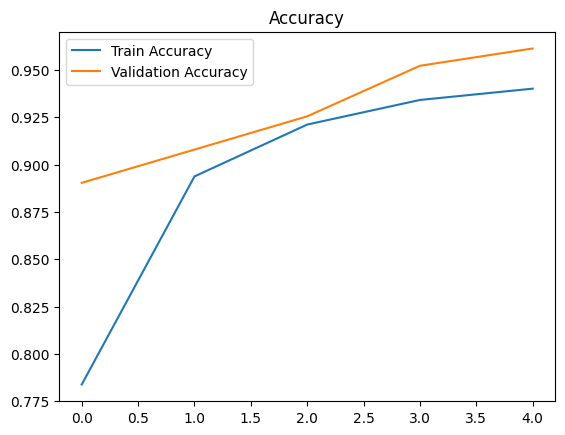

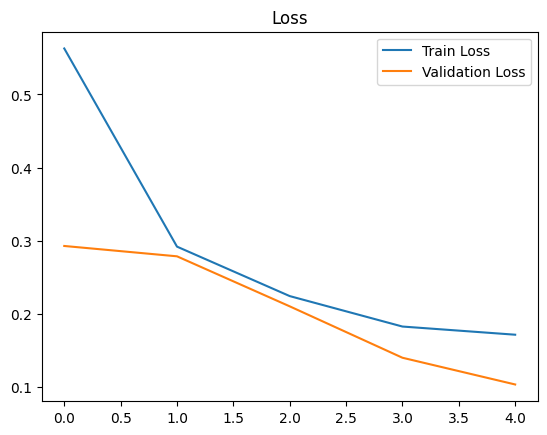

In [8]:
# Plot Accuracy & Loss
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [17]:
# Prediction on New Image
from tensorflow.keras.preprocessing import image
import os

folder = "Apple/Test/Apple Scab"
img_name = os.listdir(folder)[1]

img_path = os.path.join(folder, img_name)

img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

class_names = list(train_data.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

1/1 [==============================] - 0s 55ms/step
Predicted Class: Black Rot
